# # Projeto 1 — Comparador de Ações Brasileiras

## Este projeto compara ações brasileiras listadas na B3 usando dados históricos do Yahoo Finance.

O código analisa os ativos escolhidos entre 01/01/2015 e 31/08/2025 e retorna:

- retorno total;
- retorno anualizado;
- volatilidade anualizada;
- índice de Sharpe aproximado;
- máximo drawdown;
- correlação entre os ativos;
- gráfico de evolução de R$ 10.000 investidos;
- gráfico de drawdown;
- ranking final por retorno total.

Exemplo de ativos analisados:

PETR4.SA, VALE3.SA, WEGE3.SA

Tickers analisados:
['PETR4.SA', 'VALE3.SA', 'WEGE3.SA']

Baixando dados de PETR4.SA...
PETR4.SA baixado com sucesso.

Baixando dados de VALE3.SA...
VALE3.SA baixado com sucesso.

Baixando dados de WEGE3.SA...
WEGE3.SA baixado com sucesso.

Dados finais utilizados na análise:
Data inicial: 2015-01-02
Data final: 2025-08-29
Quantidade de dias úteis: 2653

Primeiras linhas da base:


,PETR4.SA,VALE3.SA,WEGE3.SA
Date,,,
2015-01-02 00:00:00-02:00,2.460992,9.982888,4.719267
2015-01-05 00:00:00-02:00,2.250651,9.832767,4.751443
2015-01-06 00:00:00-02:00,2.177031,10.226828,4.680963
2015-01-07 00:00:00-02:00,2.279573,10.602126,4.627334
2015-01-08 00:00:00-02:00,2.426811,10.714713,4.705477



Últimas linhas da base:


,PETR4.SA,VALE3.SA,WEGE3.SA
Date,,,
2025-08-25 00:00:00-03:00,29.321335,52.187904,36.230591
2025-08-26 00:00:00-03:00,29.110872,52.653530,36.096157
2025-08-27 00:00:00-03:00,29.330900,52.625023,36.240196
2025-08-28 00:00:00-03:00,29.589197,52.644028,36.317017
2025-08-29 00:00:00-03:00,29.751827,52.796070,36.163372


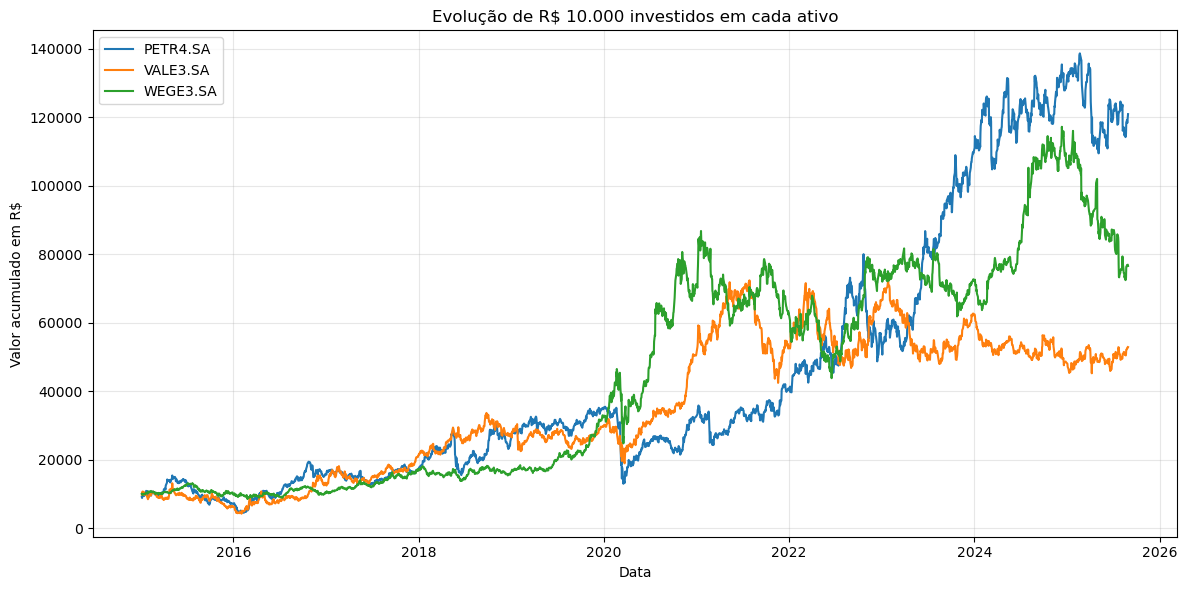


=== Estatísticas principais ===


,Retorno total (%),Retorno anualizado (%),Volatilidade anualizada (%),Sharpe aproximado
PETR4.SA,1108.94,26.35,46.20,0.57
VALE3.SA,428.87,16.92,42.62,0.40
WEGE3.SA,666.29,21.06,33.44,0.63



=== Estatísticas com máximo drawdown ===


,Retorno total (%),Retorno anualizado (%),Volatilidade anualizada (%),Sharpe aproximado,Máximo drawdown (%)
PETR4.SA,1108.94,26.35,46.20,0.57,-70.89
VALE3.SA,428.87,16.92,42.62,0.40,-67.58
WEGE3.SA,666.29,21.06,33.44,0.63,-49.51


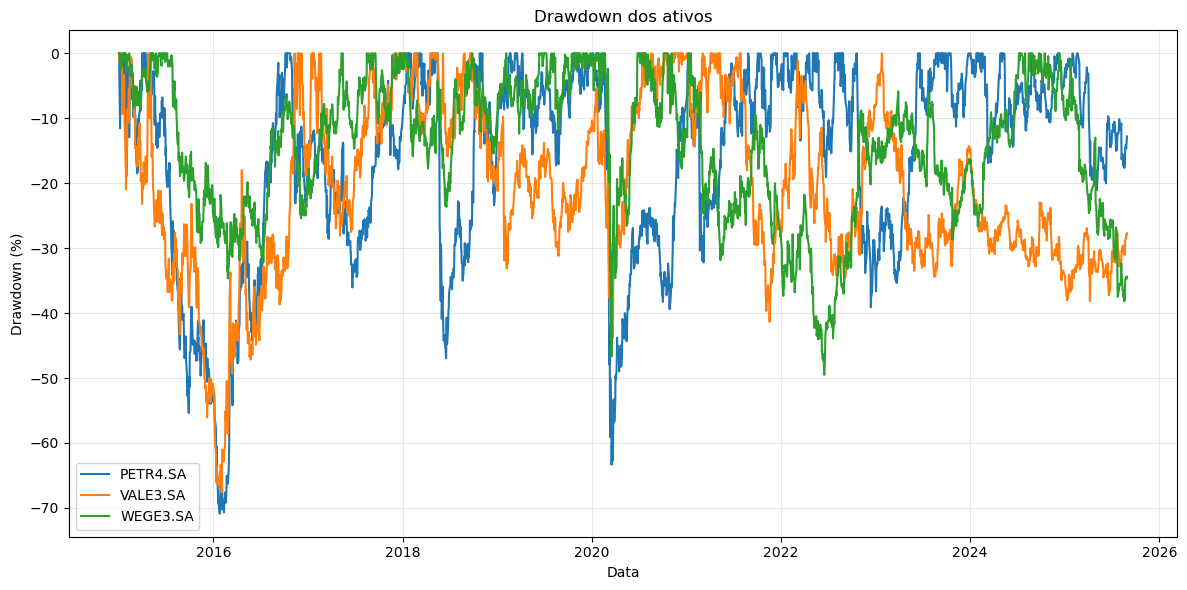


=== Matriz de correlação dos retornos diários ===


,PETR4.SA,VALE3.SA,WEGE3.SA
PETR4.SA,1.00,0.44,0.29
VALE3.SA,0.44,1.00,0.21
WEGE3.SA,0.29,0.21,1.00


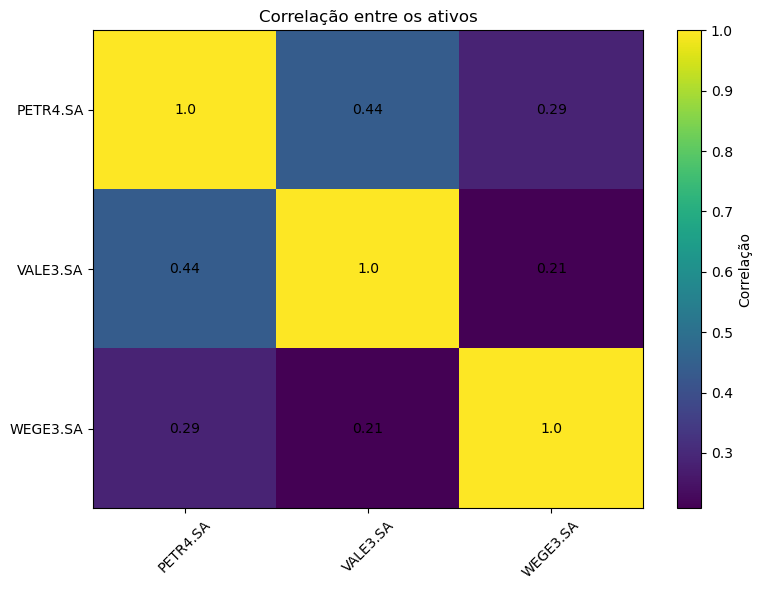


=== Ranking por retorno total ===


,Retorno total (%),Retorno anualizado (%),Volatilidade anualizada (%),Sharpe aproximado,Máximo drawdown (%)
PETR4.SA,1108.94,26.35,46.20,0.57,-70.89
WEGE3.SA,666.29,21.06,33.44,0.63,-49.51
VALE3.SA,428.87,16.92,42.62,0.40,-67.58



Análise concluída com sucesso.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf


# ------------------------------------------------------------
# 1) CONFIGURAÇÕES DO USUÁRIO
# ------------------------------------------------------------

tickers_texto = "PETR4.SA, VALE3.SA, WEGE3.SA"

data_inicio = "2015-01-01"
data_fim = "2025-09-01"  # pega até 31/08/2025, pois o fim é exclusivo

valor_inicial = 10000


# ------------------------------------------------------------
# 2) PREPARAR LISTA DE TICKERS
# ------------------------------------------------------------

tickers = []

for ticker in tickers_texto.split(","):
    ticker = ticker.strip().upper()
    
    if ticker == "":
        continue
    
    # Se o usuário escrever PETR4 em vez de PETR4.SA,
    # o código adiciona .SA automaticamente.
    if not ticker.endswith(".SA"):
        ticker = ticker + ".SA"
    
    tickers.append(ticker)

tickers = list(dict.fromkeys(tickers))

if len(tickers) < 2:
    raise ValueError("Escolha pelo menos 2 tickers para comparar.")

print("Tickers analisados:")
print(tickers)


# ------------------------------------------------------------
# 3) BAIXAR DADOS DO YAHOO FINANCE
# ------------------------------------------------------------

precos = pd.DataFrame()
tickers_com_erro = []

for ticker in tickers:
    print(f"\nBaixando dados de {ticker}...")

    try:
        dados = yf.Ticker(ticker).history(
            start=data_inicio,
            end=data_fim,
            auto_adjust=True,
            actions=False
        )

        if dados.empty:
            print(f"Não foram encontrados dados para {ticker}.")
            tickers_com_erro.append(ticker)
            continue

        if "Close" not in dados.columns:
            print(f"A coluna Close não foi encontrada para {ticker}.")
            tickers_com_erro.append(ticker)
            continue

        precos[ticker] = dados["Close"]

        print(f"{ticker} baixado com sucesso.")

    except Exception as erro:
        print(f"Erro ao baixar {ticker}: {erro}")
        tickers_com_erro.append(ticker)


# ------------------------------------------------------------
# 4) VALIDAR OS DADOS
# ------------------------------------------------------------

precos = precos.sort_index()
precos = precos.dropna()

if precos.empty:
    raise ValueError("Nenhum dado válido foi baixado. Verifique os tickers e a conexão com a internet.")

if precos.shape[1] < 2:
    raise ValueError("Foram encontrados dados válidos para menos de 2 ativos. Escolha mais tickers.")

print("\nDados finais utilizados na análise:")
print(f"Data inicial: {precos.index.min().date()}")
print(f"Data final: {precos.index.max().date()}")
print(f"Quantidade de dias úteis: {len(precos)}")

print("\nPrimeiras linhas da base:")
display(precos.head())

print("\nÚltimas linhas da base:")
display(precos.tail())


# ------------------------------------------------------------
# 5) CALCULAR RETORNOS DIÁRIOS
# ------------------------------------------------------------

retornos = precos.pct_change().dropna()

if retornos.empty:
    raise ValueError("Não há retornos suficientes para calcular as estatísticas.")


# ------------------------------------------------------------
# 6) RETORNO ACUMULADO
# ------------------------------------------------------------

retorno_acumulado = (1 + retornos).cumprod()

plt.figure(figsize=(12, 6))

for ticker in retorno_acumulado.columns:
    plt.plot(
        retorno_acumulado.index,
        retorno_acumulado[ticker] * valor_inicial,
        label=ticker
    )

plt.title("Evolução de R$ 10.000 investidos em cada ativo")
plt.xlabel("Data")
plt.ylabel("Valor acumulado em R$")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 7) ESTATÍSTICAS PRINCIPAIS
# ------------------------------------------------------------

estatisticas = pd.DataFrame(index=precos.columns)

anos = (precos.index[-1] - precos.index[0]).days / 365.25

retorno_total = (precos.iloc[-1] / precos.iloc[0]) - 1
retorno_anualizado = (precos.iloc[-1] / precos.iloc[0]) ** (1 / anos) - 1
volatilidade_anualizada = retornos.std() * np.sqrt(252)

estatisticas["Retorno total (%)"] = retorno_total * 100
estatisticas["Retorno anualizado (%)"] = retorno_anualizado * 100
estatisticas["Volatilidade anualizada (%)"] = volatilidade_anualizada * 100
estatisticas["Sharpe aproximado"] = retorno_anualizado / volatilidade_anualizada

print("\n=== Estatísticas principais ===")
display(estatisticas.round(2))


# ------------------------------------------------------------
# 8) MÁXIMO DRAWDOWN
# ------------------------------------------------------------

drawdowns = pd.DataFrame(index=precos.index)

for ticker in precos.columns:
    pico_acumulado = precos[ticker].cummax()
    drawdown = (precos[ticker] / pico_acumulado) - 1
    drawdowns[ticker] = drawdown

max_drawdown = drawdowns.min() * 100

estatisticas["Máximo drawdown (%)"] = max_drawdown

print("\n=== Estatísticas com máximo drawdown ===")
display(estatisticas.round(2))


plt.figure(figsize=(12, 6))

for ticker in drawdowns.columns:
    plt.plot(drawdowns.index, drawdowns[ticker] * 100, label=ticker)

plt.title("Drawdown dos ativos")
plt.xlabel("Data")
plt.ylabel("Drawdown (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 9) MATRIZ DE CORRELAÇÃO
# ------------------------------------------------------------

correlacao = retornos.corr()

print("\n=== Matriz de correlação dos retornos diários ===")
display(correlacao.round(2))

plt.figure(figsize=(8, 6))
plt.imshow(correlacao, aspect="auto")
plt.colorbar(label="Correlação")

plt.xticks(
    ticks=range(len(correlacao.columns)),
    labels=correlacao.columns,
    rotation=45
)

plt.yticks(
    ticks=range(len(correlacao.index)),
    labels=correlacao.index
)

for i in range(len(correlacao.index)):
    for j in range(len(correlacao.columns)):
        plt.text(
            j,
            i,
            round(correlacao.iloc[i, j], 2),
            ha="center",
            va="center"
        )

plt.title("Correlação entre os ativos")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 10) RANKING FINAL
# ------------------------------------------------------------

ranking = estatisticas.sort_values("Retorno total (%)", ascending=False)

print("\n=== Ranking por retorno total ===")
display(ranking.round(2))

print("\nAnálise concluída com sucesso.")